# Data_Preprocessing

## Step 0:Libraries

In [9]:
import pandas as pd
import re

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


## Step 1:Conversion of gestational weeks units

### The data format of the "gestational age" column:

<img src="./Images/picture1.png">

![gestational age format](Images/picture1.png)

### First, convert it according to the formula in the paper:

<img src="./Images/picture2.png">

In [5]:
def convert_gestational_age(value):
    """
    将检测孕周转换为小数
    """
    if isinstance(value, str):
        value = value.strip()
        # 匹配 "11w+6" 或 "11W+6"
        match_plus = re.match(r"(\d+)[wW]\+(\d+)", value)
        if match_plus:
            weeks = int(match_plus.group(1))
            days = int(match_plus.group(2))
            return round(weeks + days / 7, 2)

        # 匹配 "13w" 或 "13W"
        match_week = re.match(r"(\d+)[wW]", value)
        if match_week:
            return int(match_week.group(1))

    return value

### However, using Pandas brings about a problem:
Pandas or Excel automatically identifies "dates" as the datetime type,
and since datetime by default requires a time component, it will automatically pad it with 00:00:00.
To avoid this problem, a new function is required.

In [6]:
def clean_last_menstruation(value):
    """
    清理“末次月经”列:
        datetime → 'YYYY/MM/DD'
        '2023/2/1 0:00:00' → '2023/2/1'
    """
    if pd.isna(value):
        return value  # 保留空值

    # 如果是 datetime 类型
    if hasattr(value, "strftime"):
        return value.strftime("%Y/%m/%d")

    # 如果是字符串
    if isinstance(value, str):
        return value.replace(" 0:00:00", "").strip()

    return str(value)  # 其它情况强制转为字符串

### Finally, we will write a general function.
According to the requirements of the question, we will consider the data in the "Y chromosome concentration" column with a value greater than 0.04 as being accurately "NIPT test" results.

In [7]:
def process_excel(input_file, output_file):
    # 读取“男胎检测数据”工作表
    df = pd.read_excel(input_file, sheet_name="男胎检测数据")

    # 生成“NIPT准确性”列
    df["NIPT准确性"] = df["Y染色体浓度"].apply(lambda x: "是" if x > 0.04 else "否")

    # 转换“检测孕周”列
    if "检测孕周" in df.columns:
        df["检测孕周"] = df["检测孕周"].apply(convert_gestational_age)

    # 清理“末次月经”列
    if "末次月经" in df.columns:
        df["末次月经"] = df["末次月经"].apply(clean_last_menstruation)

    # 保存到新的 Excel 文件
    df.to_excel(output_file, index=False)
    print(f"处理完成，保存为: {output_file}")

In [8]:
if __name__ == "__main__":
    input_path = "../Data/附件.xlsx"  # 输入文件路径
    output_path = "../Data/男胎检测数据_处理后.xlsx"  # 输出文件路径
    process_excel(input_path, output_path)

处理完成，保存为: ../Data/男胎检测数据_处理后.xlsx


## Step 2:Missing Value Handling

### Missing value plotting function

In [10]:
def plot_missing_bar(series, title, y_label, save_path, xtick_step=200):
    """
    缺失值柱状图绘制函数
    """
    arr = series.isna().astype(int).to_numpy()[None, :]
    cmap = ListedColormap(["#1f77b4", "#d62728"])

    fig, ax = plt.subplots(figsize=(12, 2.5))
    ax.imshow(arr, aspect="auto", cmap=cmap, vmin=0, vmax=1)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Index", fontsize=12)
    ax.set_yticks([0])
    ax.set_yticklabels([y_label], fontsize=12)

    # Add index ticks
    n = len(series)
    xticks = np.arange(0, n, xtick_step)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, rotation=45, fontsize=9)

    # Legend
    legend_elements = [
        Patch(facecolor="#1f77b4", label="Present"),
        Patch(facecolor="#d62728", label="Missing")
    ]
    ax.legend(handles=legend_elements, loc="upper right",
              bbox_to_anchor=(1.0, 1.6), ncol=2, frameon=False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

### General function for missing value

In [11]:
path = "../Data/附件.xlsx"
male = pd.read_excel(path, sheet_name="男胎检测数据")
female = pd.read_excel(path, sheet_name="女胎检测数据")

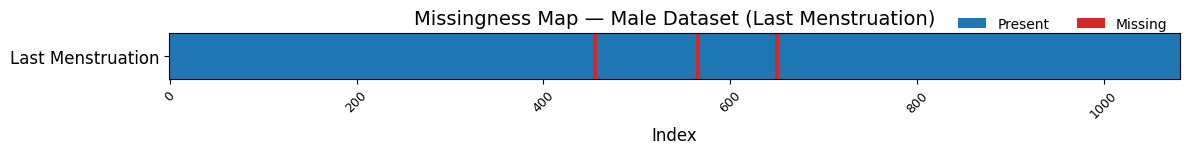

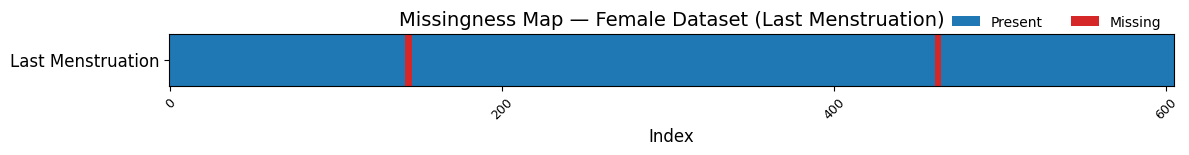

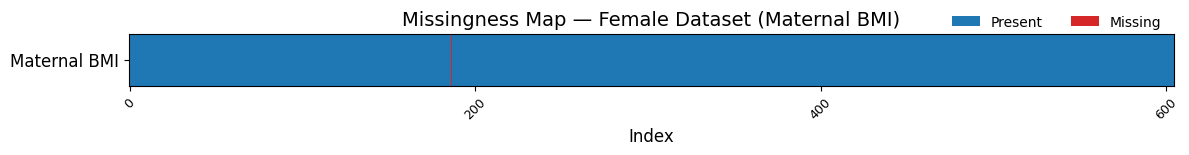

In [12]:
# 男胎数据集——末次月经缺失值
plot_missing_bar(
    male["末次月经"],
    title="Missingness Map — Male Dataset (Last Menstruation)",
    y_label="Last Menstruation",
    save_path="./Images/picture3.png"
)

# 女胎数据集——末次月经缺失值
plot_missing_bar(
    female["末次月经"],
    title="Missingness Map — Female Dataset (Last Menstruation)",
    y_label="Last Menstruation",
    save_path="./Images/picture4.png"
)

# 女胎数据集——BMI缺失值
plot_missing_bar(
    female["孕妇BMI"],
    title="Missingness Map — Female Dataset (Maternal BMI)",
    y_label="Maternal BMI",
    save_path="./Images/picture5.png"
)

### The final result of missing value:
Since the indicators of the last menstrual period can be indirectly reflected by the gestational weeks, and their importance is low,
therefore, no processing is carried out on them here.
At the same time, for the case where the BMI of one sample is missing, it is restored by using the height-weight calculation formula.


![](Images/picture3.png)
<img src="Images/picture3.png">

![](Images/picture4.png)
<img src="Images/picture4.png">

![](Images/picture5.png)
<img src="Images/picture5.png">